In [1]:
# ---------------
#  T o  -   D o :
# ---------------

# (*) ADD OMNI excel generation 
# (*) START OMNI - execute experiments one-by-one


In [1]:
import matplotlib.pyplot as plt
import pandas            as pd
import numpy             as np
import matplotlib        as mpl
import copy

from   scipy.interpolate import interp1d
from   dataclasses       import dataclass, field, fields
from   itertools         import accumulate, chain

# My stuff
from doe_sampling.doe_sampler         import DoESampler


import exp_generation.profile_gen_helper_funcs

from exp_generation.profile_gen      import DefineProcessParameter
from exp_generation.profile_gen      import ProfileCreator
from exp_generation.profile_gen      import ExperimentProfileParameters
from exp_generation.profile_gen      import ExperimentProfileStorage
from exp_generation.profile_gen      import ExpComponentGen
from exp_generation.profile_gen      import ProfileGenerator

from exp_generation.pump_calibration import PumpRateConverter


mpl.rcParams.update({'font.size': 7,'axes.labelsize': 7,'axes.titlesize': 7,'xtick.labelsize': 7,'ytick.labelsize': 7,'legend.fontsize': 7,
                     'grid.alpha': 0.5, 'grid.linewidth': 0.7,'grid.linestyle': '-', 'xtick.minor.visible': True, 'ytick.minor.visible': True,})

In [4]:
as_pump_cal_location   = r"C:\Users\abotondo\OneDrive - purdue.edu\Pfizer\2. Purdue Experiments\Evaluated expts\AS_PUMP_CAL\expttsd1.csv"
solu_pump_cal_location = r"C:\Users\abotondo\OneDrive - purdue.edu\Pfizer\2. Purdue Experiments\Experiments\PUMP_CAL\expttsd1_SOLU.csv"
solv_pump_cal_location = r"C:\Users\abotondo\OneDrive - purdue.edu\Pfizer\2. Purdue Experiments\Experiments\PUMP_CAL\expttsd1_SOLV.csv"

doe_sampler          = DoESampler()                             # ...generating the settings for Experiments
component_gen        = ExpComponentGen(exp_generation.profile_gen_helper_funcs)            # ...functions for experiment section generation
exp_par              = ExperimentProfileParameters()            # ...storing the parameters for DoE profile generation
profiles             = ProfileGenerator(exp_par,                # ...generating epxerimental profiles 
                                         component_gen,
                                         exp_generation.profile_gen_helper_funcs)       

as_rate_converter             = PumpRateConverter(as_pump_cal_location,    # ...generating 'mass rate - pump rpm' calibraiton automatically
                                               'File  W: AS ',
                                               'File R: Mass ')  
solution_rate_converter       = PumpRateConverter(solu_pump_cal_location,  # ...generating 'mass rate - pump rpm' calibraiton automatically
                                               'P01:Value (Setpt)',
                                               'File R: Mass ')  
solvent_rate_converter        = PumpRateConverter(solv_pump_cal_location,  # ...generating 'mass rate - pump rpm' calibraiton automatically
                                               'P01:Value (Setpt)',
                                               'File R: Mass ')  
cleaning_sol_rate_converter   = PumpRateConverter(solv_pump_cal_location,  # ...generating 'mass rate - pump rpm' calibraiton automatically
                                               'P01:Value (Setpt)',
                                               'File R: Mass ') 

exp_storage              = ExperimentProfileStorage(as_rate_converter,     # ...storing experimental DoE profiles      
                                                    solution_rate_converter,
                                                    solvent_rate_converter,
                                                    cleaning_sol_rate_converter) 

In [6]:
# ---------------------------------
# I. DEFINE DATA FOR DoE Generation
# ---------------------------------

# 0. Define parameters for DoE (min, max, active parameters)
# by changing exp_par.X

exp_par.if_ARR = False              
exp_par.if_AS  = False               
exp_par.AS_add_time.if_in_doe = False        
exp_par.if_cool_in_exp = False      
exp_par.t_cool.if_in_doe = False            
exp_par.T_final.if_in_doe  = False           
exp_par.aceton_boil_out_T  = 20
exp_par.if_diss_initial    = False
exp_par.seed.if_in_doe     = False
exp_par.t_h_seed.value = 0.05
exp_par.t_h_clean.value = 0.05
exp_par.t_eq.value = 0.05
exp_par.t_h_solution.value = 0.05
exp_par.wait_after_exp = 0.05
exp_par.t_before_open_valve = 0.001
exp_par.cleaning_sol_amount.value = 10
exp_par.solv_amount.value         = 10
exp_par.Initial_sol_amount.value  = 10
exp_par.t_h_clean.value           = 0.01



# 1. Correct the settings, so that if a section is false, all of its settings are neglected
exp_par   = exp_generation.profile_gen_helper_funcs.exp_par_condition_corr(exp_par)

# 2. Count the dimensions subject to change
dimensions  = doe_sampler.dim_counter(exp_par)

# 3. Set the weights and the number of samples to take if 'not Factorial' design
weights = dimensions*[1] # weights to ExperimentProfileParameters !! - not working currently
samples = 1

Fract   = 0
TYPE    = 'GREEDY'

if_sampling  = False 

if dimensions < 1 or samples < 2:
    
    print(f'Dimension of DoE is {dimensions} !')
    print(f'No. of sample in DoE is {samples} !')
    
    print(f'Generating {samples} sample(s) using the identical, default settings !')
    if_sampling  = False 

elif Fract > 2 and TYPE == 'FACT':
    
    print('Select Fract to be: 0>=Fract>=2}')
    
else:
    
    if_sampling = True


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
# - - - - - - - - - - -- - - - - - - - -   S t a r t    s a m p l i n g   - - - - - - - - - - - - - - - - - - - - - - - - 
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

#-----------------------------------------------------------
# II. Convert the sampled points to actual parameter values:
#-----------------------------------------------------------
if if_sampling:
    # Generate DoE either Factorial or Optimal sampling-based
    DoE_sampled = doe_sampler.doe_generator(1,samples,dimensions,weights,TYPE,Fraction=Fract)[0]
    print(DoE_sampled)
    
    # Illustrate sampled points
    doe_sampler.two_dim_plotter([doe_sampler.scaler(DoE_sampled)],[TYPE])
    doe_sampler.three_dim_plotter(doe_sampler.scaler(DoE_sampled))
    DoE_sampled_scaled = doe_sampler.scaler(DoE_sampled)

# build the experimental DoE --> all profiles for each experiment    
DoE_val = dict()
for i in range(samples):
    if if_sampling: # sampling is True then take the optimal samples otherwise just use the default .values
        
        for f in fields(exp_par):
            if f.type.__name__ == "DefineProcessParameter" and getattr(exp_par, f.name).if_in_doe:
                dim_index = 0
                
                param = getattr(exp_par, f.name)
                
                new_value = doe_sampler.descaler(DoE_sampled_scaled[i,dim_index],param) # get samples
                    
                if param.if_only_minmax: # if if_only_minmax == True don't ge\t the samples, only take min or max alternating
                    if i % 2 == 0:
                        setattr(param, "value", param.min_val)
                        DoE_val[f.name] = [param.min_val]                    
                    else:
                        setattr(param, "value", param.max_val)
                        DoE_val[f.name] = [param.max_val]
                        
                else: # if if_only_minmax == False take the sampled value
                    setattr(param, "value", new_value[0])
                    DoE_val[f.name] = [new_value[0]]
                    
            if exp_par.if_ARR:
                exp_par.ARR = exp_par.ARR_types[i%len(exp_par.ARR_types)]

        dim_index += 1
            

    # if if_sampling == False: {samples} number of samples are generated with default vals. (identical profiles)
    
      
    # Generate the actual profiles and store them in the exp_storage object   

    exp_storage.add_experiment(f'exp{i+1}', profiles.generate_profiles()[0],profiles.generate_profiles()[1])
    
    # Store the changed parameters of the DoE
    exp_storage.add_doe_stage( f'exp{i+1}', pd.DataFrame(DoE_val))


Dimension of DoE is 0 !
No. of sample in DoE is 1 !
Generating 1 sample(s) using the identical, default settings !


<Figure size 640x480 with 0 Axes>

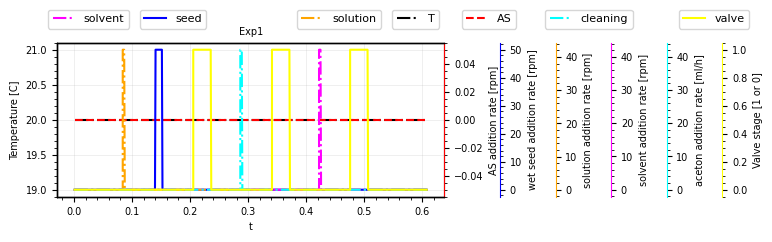

In [7]:

plllot = True

if plllot:
    for i in range(samples):
        plt.figure()
        fig, ax = plt.subplots(figsize=(5,2))
        ax_AS   = ax.twinx()

        
        ax_AS.spines['right'].set_color('red')
        
        ax_seed = ax.twinx()
        ax_seed.spines['right'].set_position(('outward', 40))
        ax_seed.spines['right'].set_color('blue')

        ax_solution   = ax.twinx()
        ax_solution.spines['right'].set_position(('outward', 80))
        ax_solution.spines['right'].set_color('orange')

        ax_solv   = ax.twinx()
        ax_solv.spines['right'].set_position(('outward', 120))
        ax_solv.spines['right'].set_color('magenta')

        ax_cl   = ax.twinx()
        ax_cl.spines['right'].set_position(('outward', 160))
        ax_cl.spines['right'].set_color('cyan')

        ax_valve   = ax.twinx()
        ax_valve.spines['right'].set_position(('outward', 200))
        ax_valve.spines['right'].set_color('yellow')
        
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='T'   ,       color = 'k',      ax = ax,         linestyle ='-.' , label='T',        ylabel='Temperature [C]')
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='AS'  ,       color = 'r',      ax = ax_AS,      linestyle ='--' , label='AS',       ylabel='AS addition rate [rpm]')
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='seed',       color = 'b',      ax = ax_seed,    linestyle = '-' , label='seed',     ylabel='wet seed addition rate [rpm]')
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='solution',   color = 'orange', ax = ax_solution,linestyle = '-.', label='solution', ylabel='solution addition rate [rpm]')
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='solvent',    color = 'magenta',ax = ax_solv,    linestyle = '-.', label='solvent',  ylabel='solvent addition rate [rpm]')
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='clean_sol',  color = 'cyan',   ax = ax_cl,      linestyle = '-.', label='cleaning', ylabel='aceton addition rate [ml/h]')
        exp_storage.data_omni[f'exp{i+1}'].plot(x = 't', y='valve_state',color = 'yellow', ax = ax_valve,   linestyle = '-' , label='valve'   , ylabel='Valve stage [1 or 0]')

        ax.set_title(f'Exp{i+1}')
        
        ax.legend(loc='best', bbox_to_anchor=(1.0, 1.25),fontsize=8)
        ax_AS.legend(loc='best', bbox_to_anchor=(1.2, 1.25),fontsize=8)
        ax_solution.legend(loc='best', bbox_to_anchor=(0.85, 1.25),fontsize=8)
        ax_solv.legend(loc='best', bbox_to_anchor=(0.2, 1.25),fontsize=8)
        ax_cl.legend(loc='best', bbox_to_anchor=(1.5, 1.25),fontsize=8)
        ax_seed.legend(loc='best', bbox_to_anchor=(0.4, 1.25),fontsize=8)
        ax_valve.legend(loc='best', bbox_to_anchor=(1.8, 1.25),fontsize=8)

        ax.grid(alpha=0.2)
        plt.show()
        

In [8]:
counter = 0
for i in range(samples):
    
    counter += 1
    to_be_printed = [f'Exp. no {i+1}: ']
    
    for j in range(dimensions):
        
        strr = f'{exp_storage.DoE[f'exp{i+1}'].columns[j]} = {exp_storage.DoE[f'exp{i+1}'].iloc[0,j]:.4f} '
        to_be_printed.append(strr)
        
    print(''.join(to_be_printed))
    

Exp. no 1: 


In [9]:
exp_storage.DoE[f'exp{i+1}'].columns

RangeIndex(start=0, stop=0, step=1)

In [10]:
false_vals = []
for k in exp_storage.data['exp1'].iloc[1:,:].index:
    if set(exp_storage.data['exp1'].iloc[k,:].values)==set(exp_storage.data['exp1'].iloc[k-1,:].values):
        false_vals.append(k)
print(false_vals)

[15, 25, 26, 27, 28]


In [11]:
for i in range(samples):
    exp_storage.data[f'exp{i+1}'] = exp_storage.data[f'exp{i+1}'].drop(index=false_vals)

In [12]:

for i in range(samples):
    if (exp_storage.data[f'exp{i+1}']['t'].diff() == 0.0).any():
        print(f'In the {i+1}th exp')
        print((exp_storage.data[f'exp{i+1}']['t'].diff() == 0.0))
        #print(exp_storage.data[f'exp{i+1}'])
    else:
        print(f'not found "0 diff" in {i+1}')

not found "0 diff" in 1


In [14]:
loc_to_save_expts = r"C:\Users\abotondo\OneDrive - purdue.edu\ECNDATA\Desktop\data_omni.xlsx"
for i in range(samples):
    DAT = pd.DataFrame(exp_storage.profile[f'exp{i+1}'])
    try:
        with pd.ExcelWriter(loc_to_save_expts, engine="openpyxl", mode="a") as writer:
            DAT.to_excel(writer, sheet_name=f"exp{i+1}", index=False)
    except:
        with pd.ExcelWriter(loc_to_save_expts, engine="openpyxl", mode="w") as writer:
            DAT.to_excel(writer, sheet_name=f"exp{i+1}", index=False)